# Sim 2 — Regime-Shift Recovery with ACI

**From the wiki page §7.2.** Same generator as Sim 1, but at `t = 12_500` the GARCH `ω` is multiplied by 5 — an abrupt vol explosion. We track rolling-500 empirical coverage under three strategies:

1. **Parametric** — frozen Gaussian band.
2. **Split CP (fixed)** — calibrated once on `[10_000, 12_500)`, never updated.
3. **Rolling sliding-window CP** — recomputes `q̂` on the last 500 residuals.
4. **ACI** — adapts the target miscoverage online (Gibbs & Candès 2021).

The story: only **active feedback** (sliding window + ACI) recovers.

In [1]:
import sys
sys.path.insert(0, '/media/ak/10E1026C4FA6006E/GitRepos/ConformalIntro/notebooks')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from utils import (
    garch_ar, setup_style, save_fig,
    split_cp_quantile, aci_update,
    coverage, width, rolling_coverage,
)
setup_style()
ALPHA = 0.10
BREAK_AT = 12_500
OMEGA_MULT = 5.0

## 1. Generate the regime-shift series

Mean dynamics unchanged; `ω` jumps by 5× at the break — vol explodes.

In [2]:
series = garch_ar(
    T=20_000, regime_break=BREAK_AT, regime_omega_mult=OMEGA_MULT, seed=1,
)
X, y, sig2 = series.X, series.y, series.sig2
train = slice(0, 10_000)
cal_pre = slice(10_000, 12_500)
test = slice(12_500, 20_000)
print(f'pre-break σ̄ = {np.sqrt(sig2[cal_pre]).mean():.4f}')
print(f'post-break σ̄ = {np.sqrt(sig2[test]).mean():.4f}')

pre-break σ̄ = 0.1341
post-break σ̄ = 0.3048


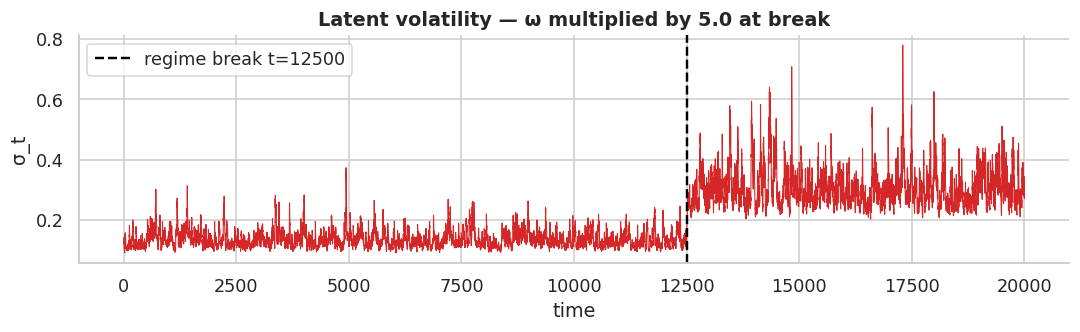

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(np.sqrt(sig2), color='#d62728', lw=0.7)
ax.axvline(BREAK_AT, color='black', ls='--', label=f'regime break t={BREAK_AT}')
ax.set_title(f'Latent volatility — ω multiplied by {OMEGA_MULT} at break')
ax.set_xlabel('time'); ax.set_ylabel('σ_t'); ax.legend()
fig.tight_layout()
save_fig(fig, 'sim2_regime_break_vol.png')
plt.show()

## 2. Train base model on pre-break data only

Critically, the base model has **never seen** the post-break regime. Whether your interval still covers there is the entire question.

In [4]:
base = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=0)
base.fit(X[train], y[train])
mu_test = base.predict(X[test])
y_test = y[test]
T_test = len(y_test)
print(f'test size: {T_test}, post-break observations only')

test size: 7500, post-break observations only


## 3. Build the four interval streams

### A. Parametric (frozen)
Fixed bandwidth from pre-break training residuals.

In [5]:
sigma_pre = (y[train] - base.predict(X[train])).std()
A_lo = mu_test - 1.645 * sigma_pre
A_hi = mu_test + 1.645 * sigma_pre

### B. Split CP, calibrated once before the break (and never updated)
This is the trap most practitioners fall into: 'I have a calibration set, therefore I have coverage forever.'

In [6]:
mu_cal = base.predict(X[cal_pre])
cal_resid = y[cal_pre] - mu_cal
q_hat_fixed = split_cp_quantile(cal_resid, alpha=ALPHA)
B_lo = mu_test - q_hat_fixed
B_hi = mu_test + q_hat_fixed
print(f'fixed q̂ = {q_hat_fixed:.4f}')

fixed q̂ = 0.2247


### C. Sliding-window split CP
Recompute `q̂` on the last 500 absolute residuals at each step. This is the WCP-window variant from the wiki's four-family taxonomy.

In [7]:
WIN = 500
pool = list(np.abs(cal_resid))
C_lo = np.zeros(T_test); C_hi = np.zeros(T_test)
for t in range(T_test):
    arr = np.asarray(pool[-WIN:])
    n_eff = len(arr)
    level = min(np.ceil((n_eff + 1) * (1 - ALPHA)) / n_eff, 1.0)
    q = np.quantile(arr, level, method='higher')
    C_lo[t] = mu_test[t] - q
    C_hi[t] = mu_test[t] + q
    pool.append(abs(y_test[t] - mu_test[t]))

### D. Adaptive Conformal Inference (ACI)
Same sliding-window residual pool, but additionally adjust `α_t` online based on whether the realised observation was covered. `γ = 0.01` is the standard default; smaller γ = slower adaptation but less noise.

In [8]:
D_lo, D_hi, alpha_traj = aci_update(
    residuals_history=np.abs(cal_resid),
    y_obs=y_test, mu=mu_test,
    alpha_target=ALPHA, gamma=0.01, window=WIN,
)
print(f'final α_t = {alpha_traj[-1]:.4f}, min α_t = {alpha_traj.min():.4f}, max α_t = {alpha_traj.max():.4f}')

final α_t = 0.1290, min α_t = 0.0010, max α_t = 0.2000


## 4. Marginal coverage over the post-break test set

In [9]:
rows = []
for name, lo, hi in [
    ('Parametric (frozen)', A_lo, A_hi),
    ('Split CP (frozen)', B_lo, B_hi),
    ('Sliding-window CP', C_lo, C_hi),
    ('ACI (γ=0.01)', D_lo, D_hi),
]:
    rows.append({'method': name, 'coverage': coverage(y_test, lo, hi), 'mean width': width(lo, hi)})
summary2 = pd.DataFrame(rows).set_index('method')
summary2

,coverage,mean width
method,,
Parametric (frozen),0.482533,0.412126
Split CP (frozen),0.519733,0.449301
Sliding-window CP,0.891333,1.073508
ACI (γ=0.01),0.900267,1.103483


## 5. Rolling coverage — the headline plot

This is the central visual: does each method recover after the shock? Parametric and frozen split CP shouldn't; sliding and ACI should.

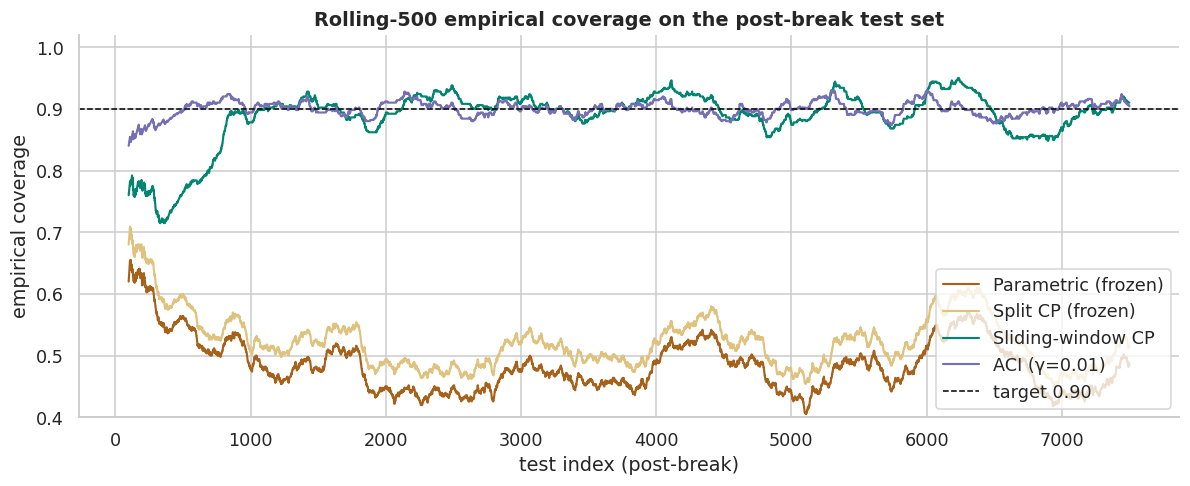

In [10]:
win = 500
rc = {
    'Parametric (frozen)': rolling_coverage(y_test, A_lo, A_hi, win=win),
    'Split CP (frozen)': rolling_coverage(y_test, B_lo, B_hi, win=win),
    'Sliding-window CP': rolling_coverage(y_test, C_lo, C_hi, win=win),
    'ACI (γ=0.01)': rolling_coverage(y_test, D_lo, D_hi, win=win),
}
fig, ax = plt.subplots(figsize=(11, 4.6))
palette = {'Parametric (frozen)':'#a6611a', 'Split CP (frozen)':'#dfc27d',
           'Sliding-window CP':'#018571', 'ACI (γ=0.01)':'#7570b3'}
for name, series_ in rc.items():
    ax.plot(series_, label=name, color=palette[name], lw=1.4)
ax.axhline(1 - ALPHA, color='black', ls='--', lw=1, label='target 0.90')
ax.set_title(f'Rolling-{win} empirical coverage on the post-break test set')
ax.set_xlabel('test index (post-break)')
ax.set_ylabel('empirical coverage')
ax.set_ylim(0.4, 1.02)
ax.legend(loc='lower right')
fig.tight_layout()
save_fig(fig, 'sim2_rolling_coverage.png')
plt.show()

## 6. α_t evolution under ACI

Watch α_t spike right after the regime break (coverage was being missed → ACI lowers α_t → wider intervals) and slowly return toward the target as coverage normalises.

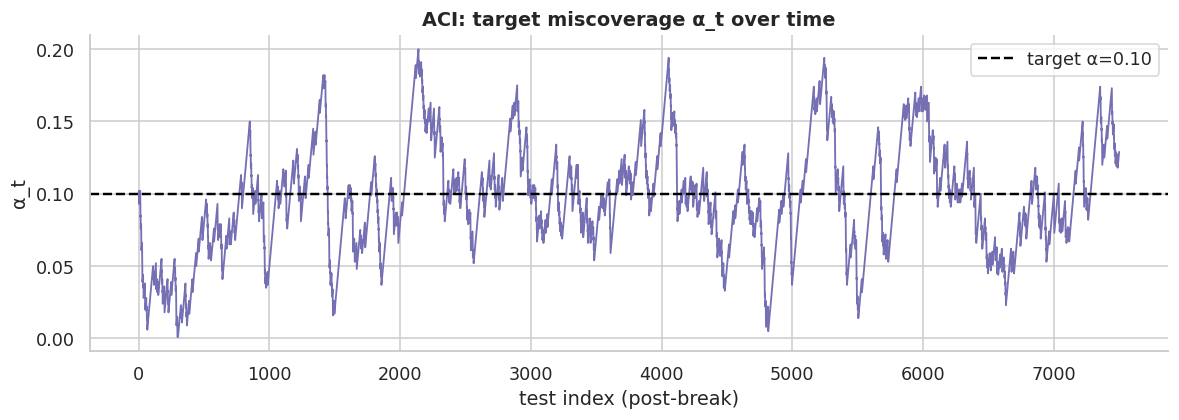

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(alpha_traj, color='#7570b3', lw=1.2)
ax.axhline(ALPHA, color='black', ls='--', label='target α=0.10')
ax.set_title('ACI: target miscoverage α_t over time')
ax.set_xlabel('test index (post-break)')
ax.set_ylabel('α_t')
ax.legend()
fig.tight_layout()
save_fig(fig, 'sim2_aci_alpha_trajectory.png')
plt.show()

## 7. Half-width over time

Adaptive methods widen during the shock and tighten as the regime stabilises. Frozen methods just sit at constant width — and pay for it in coverage.

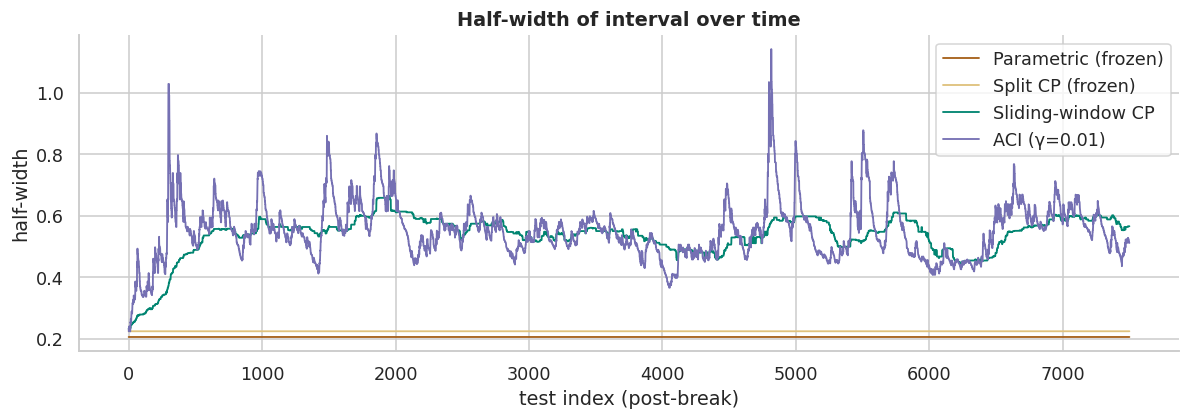

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, lo, hi in [
    ('Parametric (frozen)', A_lo, A_hi),
    ('Split CP (frozen)', B_lo, B_hi),
    ('Sliding-window CP', C_lo, C_hi),
    ('ACI (γ=0.01)', D_lo, D_hi),
]:
    ax.plot((hi - lo) / 2, label=name, color=palette[name], lw=1.2)
ax.set_title('Half-width of interval over time')
ax.set_xlabel('test index (post-break)')
ax.set_ylabel('half-width')
ax.legend(loc='upper right')
fig.tight_layout()
save_fig(fig, 'sim2_width_over_time.png')
plt.show()

## 8. Takeaway

- The parametric and frozen-split-CP intervals collapse below the 0.90 target   and never recover.
- Sliding-window CP recovers as the new high-vol residuals accumulate in the pool.
- ACI recovers faster than vanilla sliding CP because the α_t update applies   *direct* feedback from each miss.
- The width trade-off is real and visible: ACI intervals widen briefly, then settle.
- For abrupt regime shifts (the wiki's HFT post-news scenario), **ACI or its   PID variant from the Angelopoulos repo is the recommended workhorse**.